# Part A: Conditional VAE on CIFAR10

**Abstract**

This notebook builds and evaluates a baseline Conditional Variational Autoencoder (CVAE) for class-conditional image generation on the CIFAR10 dataset. The model is trained to reconstruct and generate 32x32 color images across all 10 classes, conditioned on class label, and is evaluated through reconstruction error, latent space structure, and the quality of 1000 generated images (100 per class) using manual eye-test scoring. This baseline establishes a reference point for the systematic experiments and improvements carried out in `vae_improvement.ipynb`.


## 1. Imports and Setup


In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
from torch.utils.data import TensorDataset, DataLoader
from torchvision.datasets import CIFAR10
from torchvision.utils import save_image
from sklearn.decomposition import PCA
from transformers import AutoProcessor, AutoModelForZeroShotImageClassification

# Set random seed for reproducibility.
torch.manual_seed(42)
np.random.seed(42)

C:\Users\kandy\Projects\playground (py)\env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import seaborn as sns

# Shared design system for all notebooks in dele/: a 10-color categorical palette
# (one hue per CIFAR10 class), validated for lightness, chroma, and colorblind
# separation with the dataviz skill's validator (all checks pass).
PALETTE = [
    "#A1533F",  # 0 airplane   - terracotta
    "#C08A3E",  # 1 automobile - ochre
    "#3D8049",  # 2 bird       - sage
    "#24558F",  # 3 cat        - slate blue
    "#8A3466",  # 4 deer       - plum
    "#4552A8",  # 5 dog        - indigo
    "#8C3F32",  # 6 frog       - brick red
    "#B79A2E",  # 7 horse      - mustard
    "#B5615B",  # 8 ship       - rose
    "#6B7A1A",  # 9 truck      - olive
]
sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams["figure.facecolor"] = "#fcfcfb"
plt.rcParams["axes.facecolor"] = "#fcfcfb"

## 2. Approach

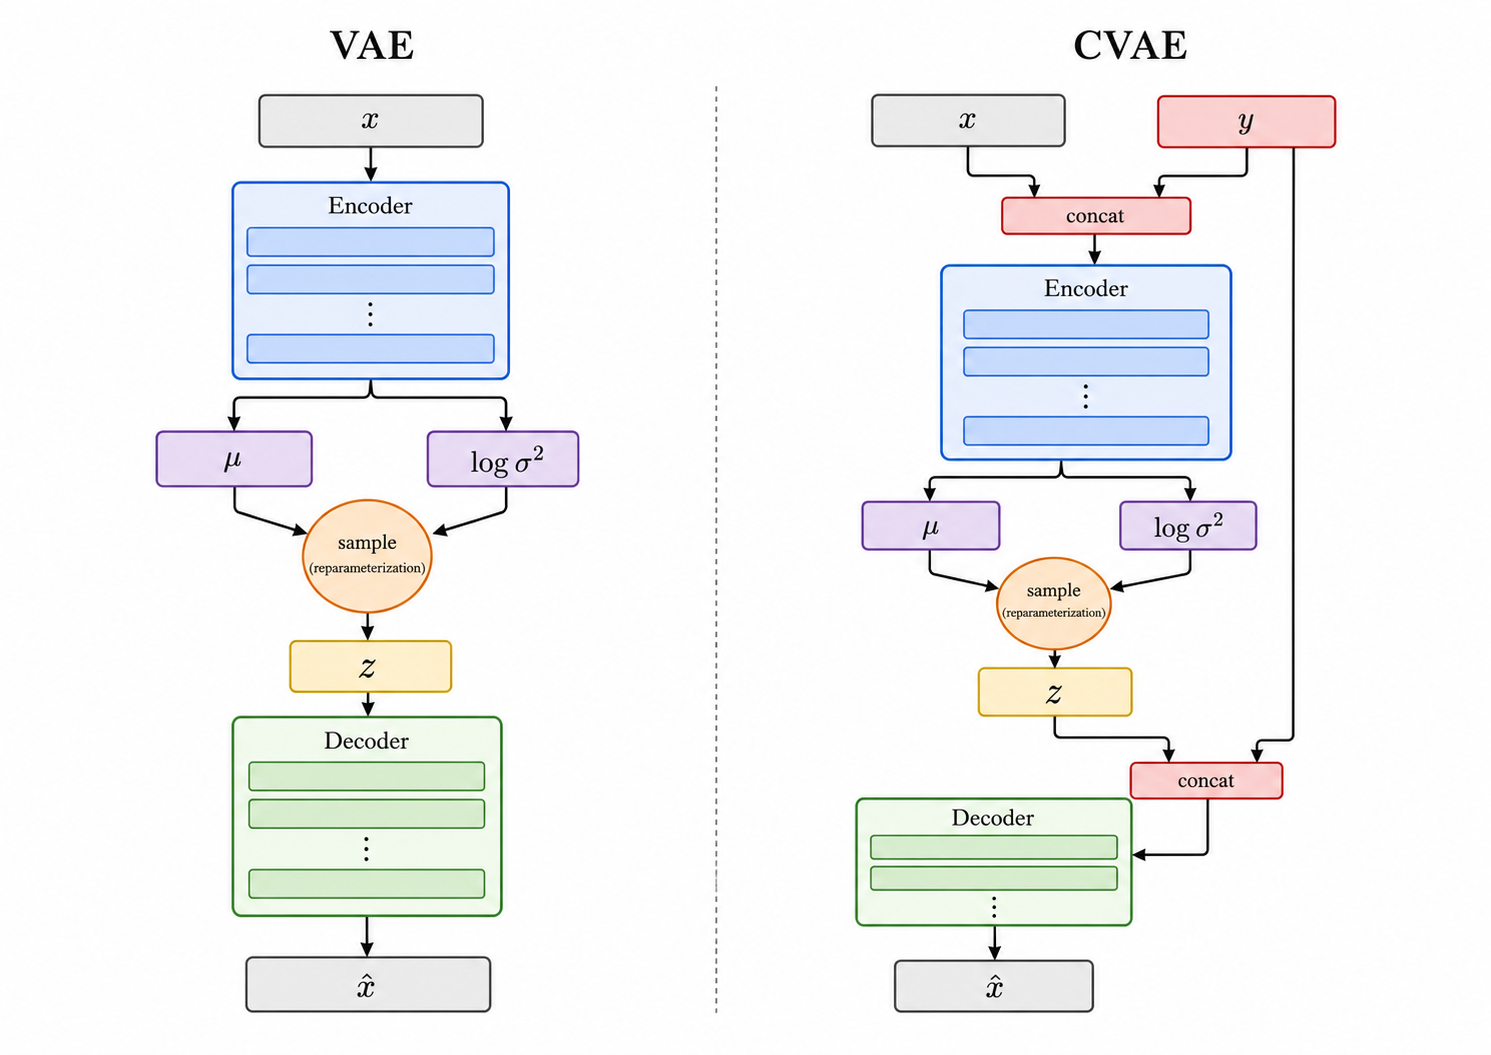

A Variational Autoencoder (VAE) is a generative model that learns to compress images into a compact latent representation and reconstruct them back, while also shaping that latent space to follow a known distribution (a standard normal) so new images can be generated by sampling from it directly. A Conditional VAE (CVAE) extends this by feeding the class label alongside the image into both the encoder and decoder, so the latent space captures shared visual variation across all classes while the label steers what specific class gets generated. This makes a CVAE well suited to this task: CIFAR10 requires generating images for 10 distinct classes on demand, which a CVAE handles directly through its label conditioning, rather than needing a separate model per class.


## 3. Preprocessing

CIFAR10 images are stored in a (32, 32, 3) shape, height, width, and 3 color channels (RGB). To prepare the data for training, we perform the following steps: normalize pixel values, encode labels, and split the data into train, validation, and test sets.


### 3.1 Normalize Pixel Values

We normalize pixel values by rescaling them from the 0-255 range to 0-1, so they are on a consistent scale suitable for our model.


In [3]:
train_set = CIFAR10(root="..", train=True, download=True)
test_set = CIFAR10(root="..", train=False, download=True)
class_names = train_set.classes

# Channel-first (N, C, H, W) layout, expected by torch's Conv2d layers.
x_train = torch.tensor(train_set.data, dtype=torch.float32).permute(0, 3, 1, 2) / 255
x_test = torch.tensor(test_set.data, dtype=torch.float32).permute(0, 3, 1, 2) / 255
y_train = torch.tensor(train_set.targets, dtype=torch.long)
y_test = torch.tensor(test_set.targets, dtype=torch.long)

print("x_train:", x_train.shape, x_train.dtype, "range:", x_train.min().item(), "-", x_train.max().item())
print("x_test: ", x_test.shape, x_test.dtype)

x_train: torch.Size([50000, 3, 32, 32]) torch.float32 range: 0.0 - 1.0
x_test:  torch.Size([10000, 3, 32, 32]) torch.float32


### 3.2 Encode Labels

We encode labels (input) using one-hot encoding, transforming a categorical class value into a numerical vector that serves the same purpose as a conditioning signal for the encoder and decoder.


In [4]:
# One-hot vectors give the encoder/decoder a fixed-length conditioning signal instead of a raw class index.
num_classes = len(class_names)
y_train_onehot = F.one_hot(y_train, num_classes=num_classes).float()
y_test_onehot = F.one_hot(y_test, num_classes=num_classes).float()

print("y_train_onehot:", y_train_onehot.shape, y_train_onehot.dtype)

y_train_onehot: torch.Size([50000, 10]) torch.float32


### 3.3 Train/Validation/Test Split

We split the data into train, validation, and test sets, so we can use some of the data to train the model and the rest to evaluate model performance. The official CIFAR10 test set (10,000 images) is kept fully held out, while the validation set is carved out of the 50,000 training images.


In [5]:
# Fixed seed so the same 5000 images are held out as validation on every run.
val_size = 5000
generator = torch.Generator().manual_seed(42)
perm = torch.randperm(len(x_train), generator=generator)
val_idx, train_idx = perm[:val_size], perm[val_size:]

x_val, y_val, y_val_onehot = x_train[val_idx], y_train[val_idx], y_train_onehot[val_idx]
x_train, y_train, y_train_onehot = x_train[train_idx], y_train[train_idx], y_train_onehot[train_idx]

print("train:", x_train.shape)
print("val:  ", x_val.shape)
print("test: ", x_test.shape)

train: torch.Size([45000, 3, 32, 32])
val:   torch.Size([5000, 3, 32, 32])
test:  torch.Size([10000, 3, 32, 32])


## 4. Sampling Layer (Reparameterization Trick)


### 4.1 The Reparameterization Trick

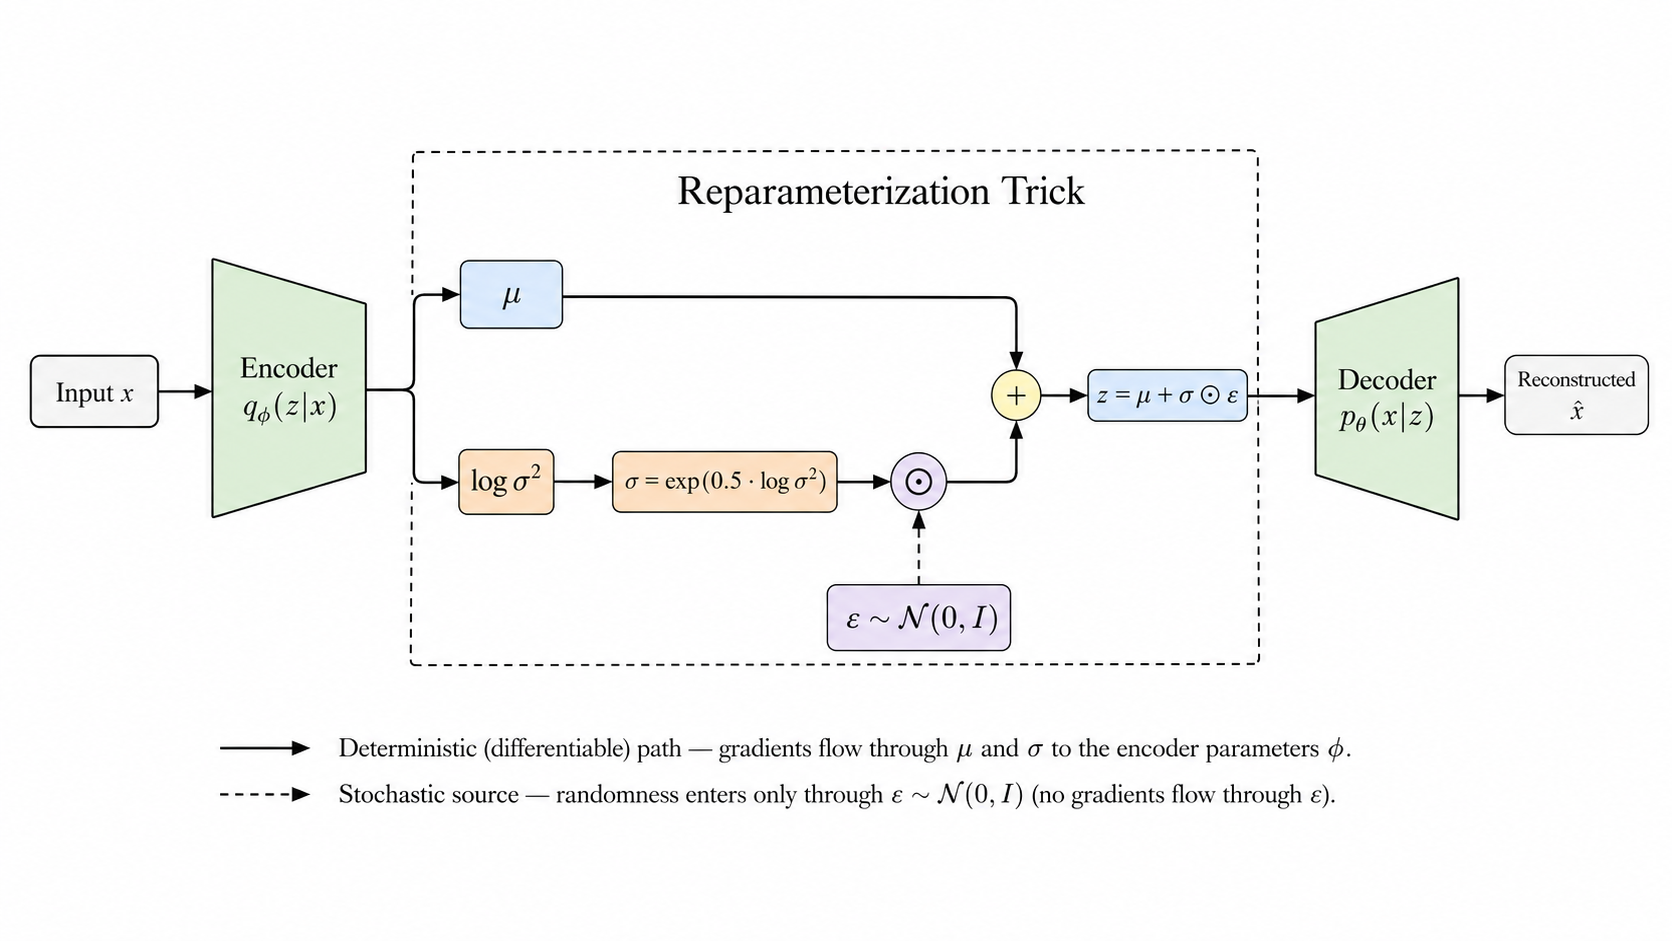

The encoder doesn't hand us a single latent vector directly, it hands us the two numbers that describe a distribution: a mean and a standard deviation. The naive approach would be to sample $z$ straight out of that distribution, but a random sampling step like that has no gradient, so training couldn't adjust the encoder's mean/standard deviation to make better samples. The reparameterization trick sidesteps this by splitting the sampling into two steps: first sample a plain, unrelated point $\epsilon$ from a standard normal distribution, then multiply it by the standard deviation and add the mean. Since the only randomness now lives in $\epsilon$ (which needs no gradient, the dashed arrow above), the mean and standard deviation stay on a fully differentiable, deterministic path (the solid arrows) all the way back to the encoder (Gundersen, 2018).


### 4.2 Objective

We aim to produce a latent vector z that behaves like a genuine random sample from the distribution the encoder predicts for a given image, N(z_mean, z_var), while keeping the sampling step differentiable so gradients can still reach the encoder during training.


In [6]:
class Sampling(nn.Module):
    """Reparameterization trick: z = z_mean + std * epsilon, epsilon ~ N(0, 1)."""

    def forward(self, z_mean, z_log_var):
        std = torch.exp(0.5 * z_log_var)
        epsilon = torch.randn_like(std)
        return z_mean + std * epsilon

### 4.3 Alternatives

There are other ways to handle this non-differentiability problem, depending on the type of latent variable involved:

-   **Gumbel-softmax**: used when the latent variable is discrete or categorical rather than continuous. It provides a continuous, differentiable relaxation of sampling from a categorical distribution, letting gradients flow even though the underlying variable is discrete.
-   **Vector quantization with a straight-through estimator (VQ-VAE)**: maps the encoder's output to the nearest vector in a learned discrete codebook, a step that has no gradient. A straight-through estimator works around this by copying gradients straight from the decoder's input back to the encoder's output during backpropagation, skipping over the non-differentiable lookup.
-   **Normalizing flows**: apply a sequence of invertible, differentiable transformations to a simple base distribution (e.g. a standard normal) to build a much richer, more expressive posterior, while still allowing exact density computation via the change-of-variables formula.

Standard Gaussian reparameterization is sufficient here since our latent space is continuous and CIFAR10 class-conditional generation does not require a highly complex posterior distribution.


## 5. Build the Conditional Encoder


### 5.1 What It Does

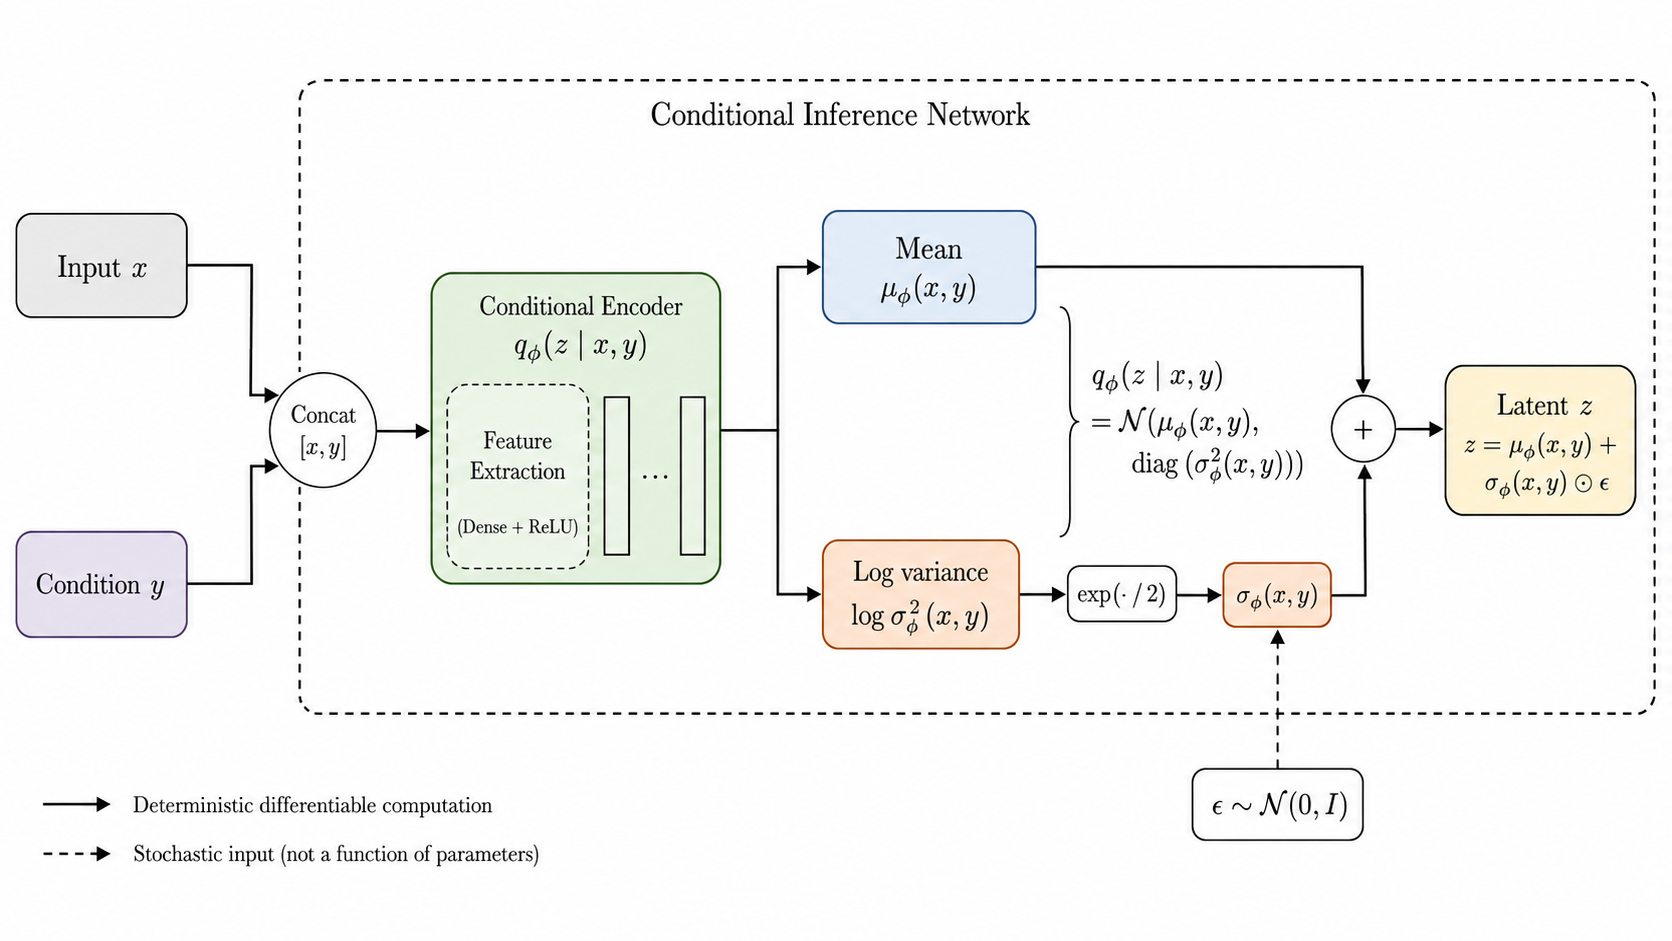

The conditional encoder takes the input image and the one-hot label, sticks them together, and runs the result through a feature extraction stack (shown above as generic dense layers; our implementation uses conv layers instead, since the input is a 32x32x3 image rather than a flat vector). Those extracted features then split into two separate output heads, a mean and a standard deviation, describing the distribution to sample this image's latent code from. That mean and standard deviation feed straight into the Sampling layer built in Section 4, which is what actually produces the latent vector $z$.


In [7]:
latent_dim = 128

class Encoder(nn.Module):
    def __init__(self, num_classes, latent_dim):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3 + num_classes, 32, kernel_size=3, stride=2, padding=1),  # 32x32 -> 16x16
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # 16x16 -> 8x8
            nn.ReLU(),
        )
        self.fc_mean = nn.Linear(64 * 8 * 8, latent_dim)
        self.fc_log_var = nn.Linear(64 * 8 * 8, latent_dim)
        self.sampling = Sampling()

    def forward(self, x, y):
        # Broadcast the one-hot label into a spatial map and concatenate it as extra channels.
        y_map = y.view(y.size(0), -1, 1, 1).expand(-1, -1, x.size(2), x.size(3))
        x = torch.cat([x, y_map], dim=1)

        features = self.conv(x).flatten(start_dim=1)
        z_mean = self.fc_mean(features)
        z_log_var = self.fc_log_var(features)
        z = self.sampling(z_mean, z_log_var)
        return z_mean, z_log_var, z

encoder = Encoder(num_classes, latent_dim)
print(encoder)

Encoder(
  (conv): Sequential(
    (0): Conv2d(13, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
  )
  (fc_mean): Linear(in_features=4096, out_features=128, bias=True)
  (fc_log_var): Linear(in_features=4096, out_features=128, bias=True)
  (sampling): Sampling()
)


## 6. Build the Conditional Decoder


### 6.1 What It Does

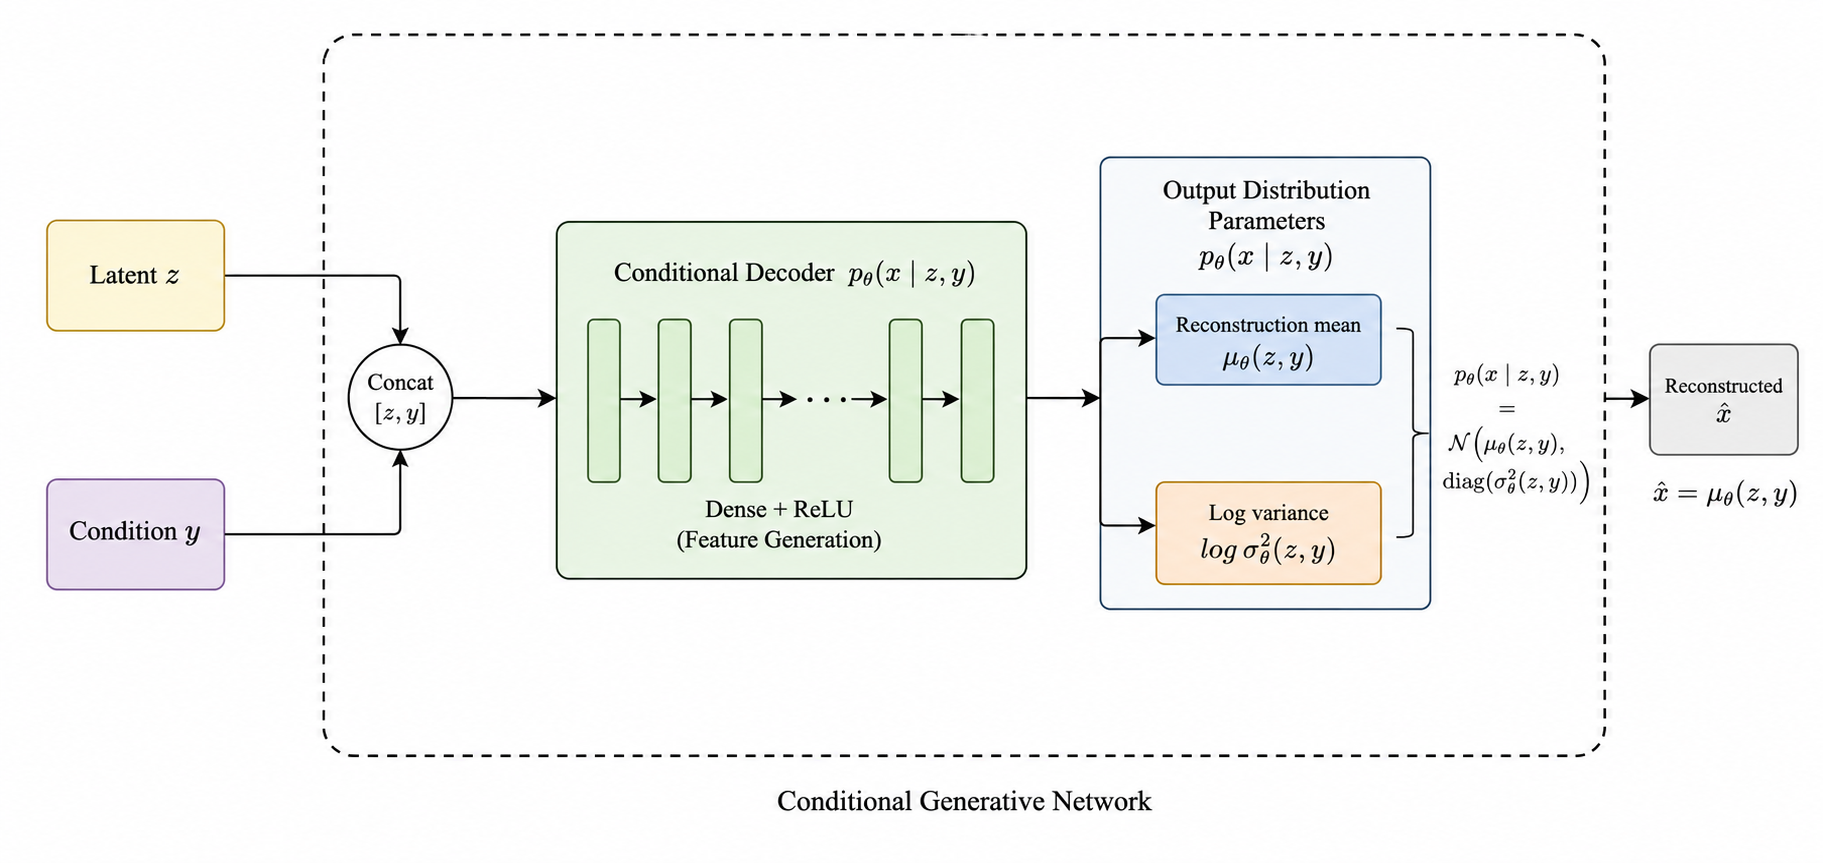

The conditional decoder takes the latent vector $z$ and the one-hot label, sticks them together, and runs the result through a feature generation stack (shown above as generic dense layers; our implementation uses a linear expansion followed by transposed conv layers instead, since the output needs to be a 32x32x3 image rather than a flat vector). The diagram's output stage splits into a mean and a standard deviation, describing a full distribution over possible reconstructions; our implementation simplifies this to a single output image straight out of a sigmoid, since we score reconstructions with binary cross-entropy (Section 7) rather than modeling per-pixel variance explicitly.


In [8]:
class Decoder(nn.Module):
    def __init__(self, num_classes, latent_dim):
        super().__init__()
        self.fc = nn.Linear(latent_dim + num_classes, 64 * 8 * 8)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),  # 8x8 -> 16x16
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=3, stride=2, padding=1, output_padding=1),  # 16x16 -> 32x32
            nn.Sigmoid(),
        )

    def forward(self, z, y):
        # Concatenate the label directly onto z since there's no spatial grid yet to broadcast it into.
        x = torch.cat([z, y], dim=1)
        x = self.fc(x).view(-1, 64, 8, 8)
        return self.deconv(x)

decoder = Decoder(num_classes, latent_dim)
print(decoder)

Decoder(
  (fc): Linear(in_features=138, out_features=4096, bias=True)
  (deconv): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(32, 3, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): Sigmoid()
  )
)


## 7. Define the CVAE Training Step


### 7.1 Loss Formulation

The total loss is the sum of a reconstruction loss, binary cross-entropy between the input image and its reconstruction, and a KL-weighted divergence term measuring how far the encoder's predicted distribution $N(\mu, \sigma^2)$ strays from the standard normal prior $N(0, I)$. Both are needed together: reconstruction loss alone would let the encoder scatter latent codes anywhere, making the space unusable for generation, while the KL term alone (with no reconstruction signal) would collapse the model into ignoring the input entirely.


In [9]:
class CVAE(nn.Module):
    def __init__(self, encoder, decoder, kl_weight=1.0):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.kl_weight = kl_weight

    def forward(self, x, y):
        z_mean, z_log_var, z = self.encoder(x, y)
        reconstruction = self.decoder(z, y)
        return reconstruction, z_mean, z_log_var

    def loss(self, x, y):
        reconstruction, z_mean, z_log_var = self(x, y)

        # Summed BCE + closed-form Gaussian KL, per Section 7.1's formulation.
        reconstruction_loss = F.binary_cross_entropy(reconstruction, x, reduction="sum") / x.size(0)
        kl_loss = -0.5 * torch.sum(1 + z_log_var - z_mean.pow(2) - z_log_var.exp(), dim=1).mean()
        total_loss = reconstruction_loss + self.kl_weight * kl_loss

        return total_loss, reconstruction_loss, kl_loss

cvae = CVAE(encoder, decoder)
print(cvae)

CVAE(
  (encoder): Encoder(
    (conv): Sequential(
      (0): Conv2d(13, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
    )
    (fc_mean): Linear(in_features=4096, out_features=128, bias=True)
    (fc_log_var): Linear(in_features=4096, out_features=128, bias=True)
    (sampling): Sampling()
  )
  (decoder): Decoder(
    (fc): Linear(in_features=138, out_features=4096, bias=True)
    (deconv): Sequential(
      (0): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
      (1): ReLU()
      (2): ConvTranspose2d(32, 3, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
      (3): Sigmoid()
    )
  )
)


## 8. Train the Model


### 8.1 Fit and Save Best Weights

We define the PyTorch training loop directly, looping over epochs and mini-batches, computing the loss, backpropagating, and stepping the optimizer, since PyTorch has no built-in `.fit()` equivalent. Train and validation losses (total, reconstruction, KL) are recorded into `history` each epoch, and whenever validation loss improves we save the model's weights, so the final checkpoint reflects the best epoch rather than just the last one.


In [10]:
# Full dataset fits in GPU memory, so keep it there and let DataLoader shuffle/batch it directly (no per-batch transfer cost).
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cvae = cvae.to(device)

x_train_dev, y_train_dev = x_train.to(device), y_train_onehot.to(device)
x_val_dev, y_val_dev = x_val.to(device), y_val_onehot.to(device)

train_loader = DataLoader(TensorDataset(x_train_dev, y_train_dev), batch_size=128, shuffle=True)

optimizer = torch.optim.Adam(cvae.parameters(), lr=1e-3)
num_epochs = 30
best_val_loss = float("inf")
history = {"train_loss": [], "train_recon": [], "train_kl": [], "val_loss": [], "val_recon": [], "val_kl": []}

for epoch in range(num_epochs):
    cvae.train()
    train_loss = train_recon = train_kl = 0.0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss, recon, kl = cvae.loss(xb, yb)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * len(xb)
        train_recon += recon.item() * len(xb)
        train_kl += kl.item() * len(xb)

    train_loss /= len(x_train_dev)
    train_recon /= len(x_train_dev)
    train_kl /= len(x_train_dev)

    # Validation runs in eval mode (no dropout/batchnorm here, but keeps the pattern consistent) and without gradients.
    cvae.eval()
    with torch.no_grad():
        val_loss, val_recon, val_kl = cvae.loss(x_val_dev, y_val_dev)
    val_loss, val_recon, val_kl = val_loss.item(), val_recon.item(), val_kl.item()

    history["train_loss"].append(train_loss)
    history["train_recon"].append(train_recon)
    history["train_kl"].append(train_kl)
    history["val_loss"].append(val_loss)
    history["val_recon"].append(val_recon)
    history["val_kl"].append(val_kl)

    # Only keep weights from the best validation epoch, since later epochs can overfit.
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(cvae.state_dict(), "vae_baseline_best.pt")

    print(f"epoch {epoch+1}/{num_epochs} - train_loss: {train_loss:.2f} - val_loss: {val_loss:.2f}")

epoch 1/30 - train_loss: 1922.10 - val_loss: 1867.15


epoch 2/30 - train_loss: 1849.88 - val_loss: 1843.68


epoch 3/30 - train_loss: 1837.18 - val_loss: 1836.34


epoch 4/30 - train_loss: 1832.45 - val_loss: 1832.64


epoch 5/30 - train_loss: 1829.32 - val_loss: 1829.86


...

epoch 26/30 - train_loss: 1818.25 - val_loss: 1820.81


epoch 27/30 - train_loss: 1818.23 - val_loss: 1820.56


epoch 28/30 - train_loss: 1817.91 - val_loss: 1820.70


epoch 29/30 - train_loss: 1817.89 - val_loss: 1820.48


epoch 30/30 - train_loss: 1817.72 - val_loss: 1820.45


### 8.2 Loss Curves

We plot the training and validation curves for total, reconstruction, and KL loss from `history`, so we can check convergence and spot overfitting at a glance rather than just reading the printed per-epoch numbers.


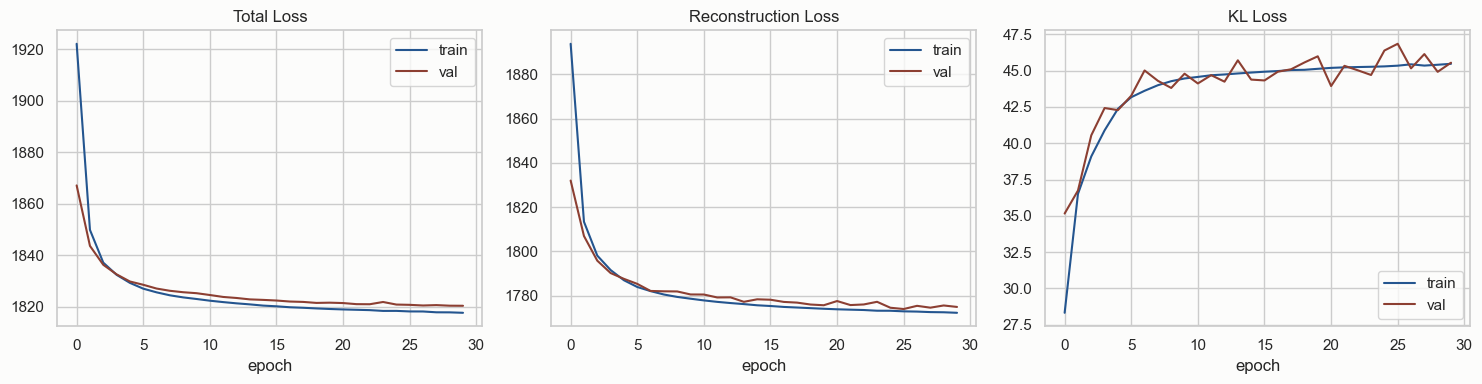

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = [("train_loss", "val_loss", "Total Loss"), ("train_recon", "val_recon", "Reconstruction Loss"), ("train_kl", "val_kl", "KL Loss")]

for ax, (train_key, val_key, title) in zip(axes, metrics):
    ax.plot(history[train_key], label="train", color=PALETTE[3])
    ax.plot(history[val_key], label="val", color=PALETTE[6])
    ax.set_title(title)
    ax.set_xlabel("epoch")
    ax.legend()

plt.tight_layout()
plt.show()

### Conclusion

Train and validation curves track closely together across all three losses, with no upward divergence in validation loss, so there's no overfitting at this baseline capacity. KL loss settles in a stable band around 45 rather than collapsing to 0 or growing unbounded, confirming the latent space is being meaningfully regularized toward the standard normal prior.


### 8.3 Reconstruction Sanity Check

We now use the trained model to encode and decode a sample of real validation images, so we can at least confirm the model is able to reconstruct images it has seen, reporting the validation reconstruction error (MSE) as a concrete number.


Validation reconstruction MSE: 0.011094069108366966


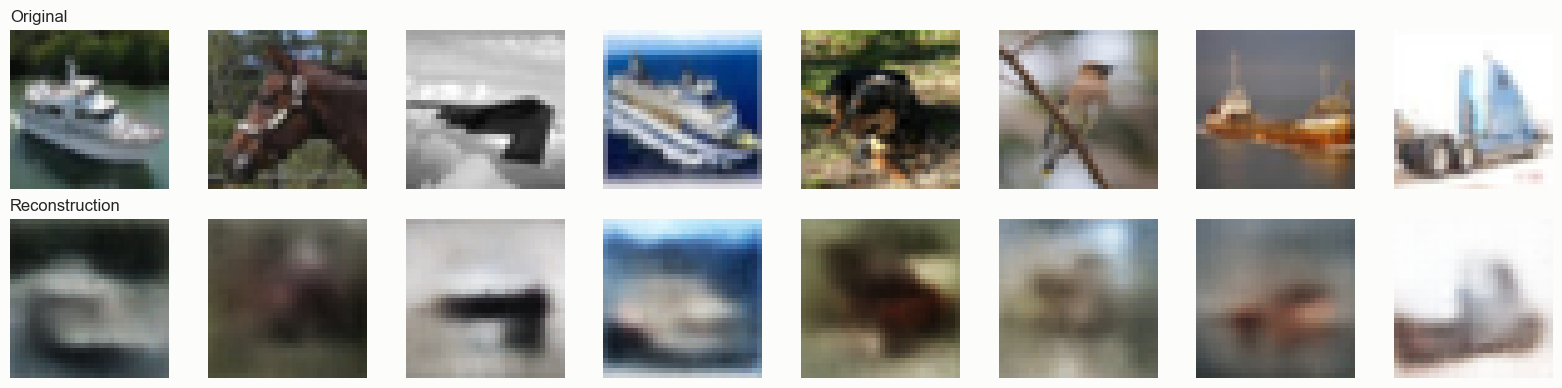

In [12]:
# Load the best checkpoint saved in 8.1, rather than whatever epoch training happened to end on.
cvae.load_state_dict(torch.load("vae_baseline_best.pt", map_location=device))
cvae.eval()

num_samples = 8
sample_idx = torch.randperm(len(x_val_dev))[:num_samples]
x_sample, y_sample = x_val_dev[sample_idx], y_val_dev[sample_idx]

with torch.no_grad():
    reconstruction, _, _ = cvae(x_sample, y_sample)

mse = F.mse_loss(reconstruction, x_sample).item()
print("Validation reconstruction MSE:", mse)

fig, axes = plt.subplots(2, num_samples, figsize=(2 * num_samples, 4))
for i in range(num_samples):
    axes[0, i].imshow(x_sample[i].permute(1, 2, 0).cpu().numpy())
    axes[0, i].axis("off")
    axes[1, i].imshow(reconstruction[i].permute(1, 2, 0).cpu().numpy())
    axes[1, i].axis("off")

axes[0, 0].set_title("Original", loc="left")
axes[1, 0].set_title("Reconstruction", loc="left")
plt.tight_layout()
plt.show()

### Conclusion

Reconstructions capture each image's dominant silhouette, color palette, and rough spatial layout (the boat's hull, the horse's head, the bird perched on its branch are all recognisable), but lose fine detail and texture, coming out consistently blurry — the printed MSE above quantifies this softness numerically. This blur is a known baseline VAE trade-off: a pixel-wise reconstruction loss rewards averaging over plausible details rather than committing to sharp textures, and it's exactly the kind of gap the improvement notebook's capacity/architecture experiments aim to close.


### 8.4 Per-Class Reconstruction Error

One sentence noting we're breaking down validation reconstruction error by class, giving quantitative evidence for which classes are harder for the model to represent.


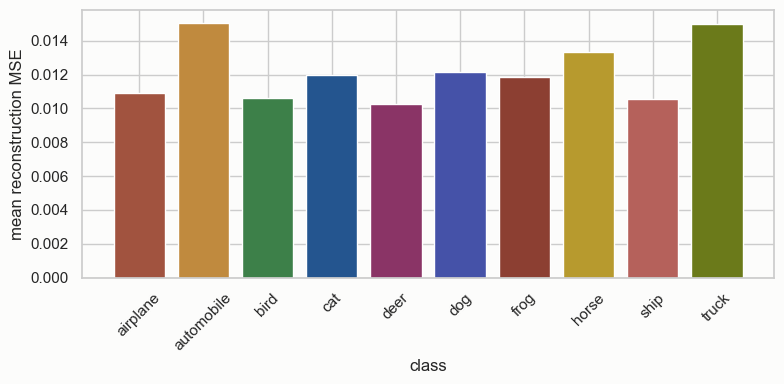

In [13]:
with torch.no_grad():
    val_reconstruction, _, _ = cvae(x_val_dev, y_val_dev)

# Per-image MSE, then averaged within each class, to see which classes reconstruct worst.
per_image_mse = ((val_reconstruction - x_val_dev) ** 2).mean(dim=[1, 2, 3]).cpu()
per_class_mse = [per_image_mse[y_val == c].mean().item() for c in range(num_classes)]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(class_names, per_class_mse, color=PALETTE)
ax.set_ylabel("mean reconstruction MSE")
ax.set_xlabel("class")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Conclusion

Automobile and truck show the highest reconstruction error (with horse close behind), while deer, ship, and bird show the lowest; this only partly matches the EDA's per-class variance ranking (Section 6), which flagged truck as the highest-variance class but automobile as the _lowest_, so automobile's high reconstruction error here is likely explained less by visual diversity and more by fine structural detail (e.g. wheels, windows) that a blurry baseline decoder struggles to reproduce even for a visually consistent class.


## 9. Latent Space Visualization


### 9.1 PCA Scatter by Class

We now visualize the data in a latent space, with its dimensionality reduced via PCA, so we can see whether the model's learned latent codes cluster by class or overlap heavily.


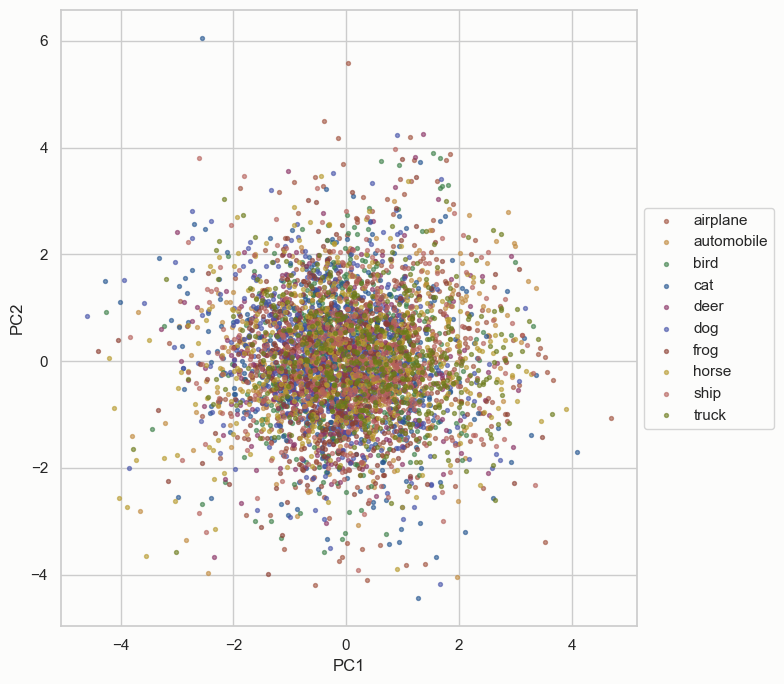

In [14]:
with torch.no_grad():
    z_mean_val, _, _ = cvae.encoder(x_val_dev, y_val_dev)

pca_coords = PCA(n_components=2, random_state=42).fit_transform(z_mean_val.cpu().numpy())

fig, ax = plt.subplots(figsize=(8, 7))
for class_idx, class_name in enumerate(class_names):
    mask = y_val == class_idx
    ax.scatter(pca_coords[mask, 0], pca_coords[mask, 1], s=8, alpha=0.6, color=PALETTE[class_idx], label=class_name)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

### Conclusion

All 10 classes overlap almost entirely into one dense central cloud, with no visually distinct per-class clusters. This is expected rather than concerning: the CVAE's objective is reconstruction plus KL regularization toward a shared $N(0, I)$ prior, not class separation, and since the class label is fed directly into the encoder/decoder as conditioning input, $z$ is free to specialize in encoding _within-class_ variation (pose, background, lighting) rather than _which_ class it is. This matches the EDA's Section 9 finding that raw pixel space showed the same lack of class separability, so this isn't a regression introduced by training, it's a consequence of the model's design.


### 9.2 Latent Interpolation

Latent interpolation is just tracing a smooth path between two latent points and decoding each step along the way, to check whether the space in between them is continuous and meaningful rather than empty or memorized.


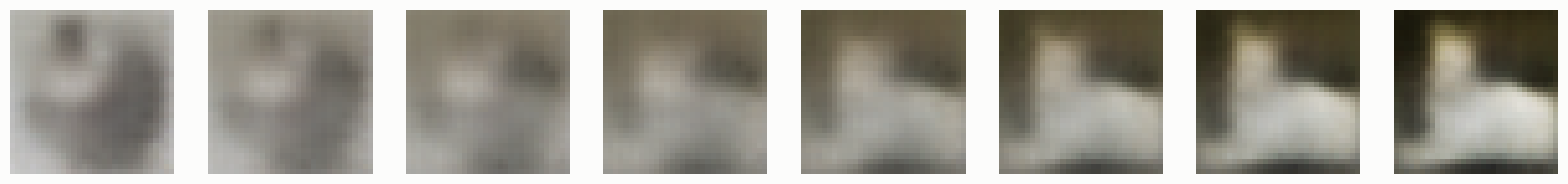

In [15]:
# Pick two validation images from the same class, so the label stays fixed and only z varies along the path.
interp_class = 3
class_idx_pool = (y_val == interp_class).nonzero(as_tuple=True)[0]
idx_a, idx_b = class_idx_pool[torch.randperm(len(class_idx_pool))[:2]]

with torch.no_grad():
    z_a, _, _ = cvae.encoder(x_val_dev[idx_a : idx_a + 1], y_val_dev[idx_a : idx_a + 1])
    z_b, _, _ = cvae.encoder(x_val_dev[idx_b : idx_b + 1], y_val_dev[idx_b : idx_b + 1])

n_steps = 8
alphas = torch.linspace(0, 1, n_steps, device=device).view(-1, 1)
z_interp = (1 - alphas) * z_a + alphas * z_b
y_interp = y_val_dev[idx_a : idx_a + 1].repeat(n_steps, 1)

with torch.no_grad():
    interp_images = cvae.decoder(z_interp, y_interp)

fig, axes = plt.subplots(1, n_steps, figsize=(2 * n_steps, 2))
for i in range(n_steps):
    axes[i].imshow(interp_images[i].permute(1, 2, 0).cpu().numpy())
    axes[i].axis("off")
plt.tight_layout()
plt.show()

### Conclusion

The interpolation grid shows a smooth, gradual transition between the two endpoints rather than an abrupt jump partway through, confirming the latent space is continuous and the model has learned a meaningful manifold rather than memorizing isolated points.


### 9.3 Per-Dimension Effect Grid

We try changing one latent dimension at a time, holding the rest fixed and the class label fixed, to see what kind of visual feature (not class, since the label is already fixed and fed in separately) each dimension controls.


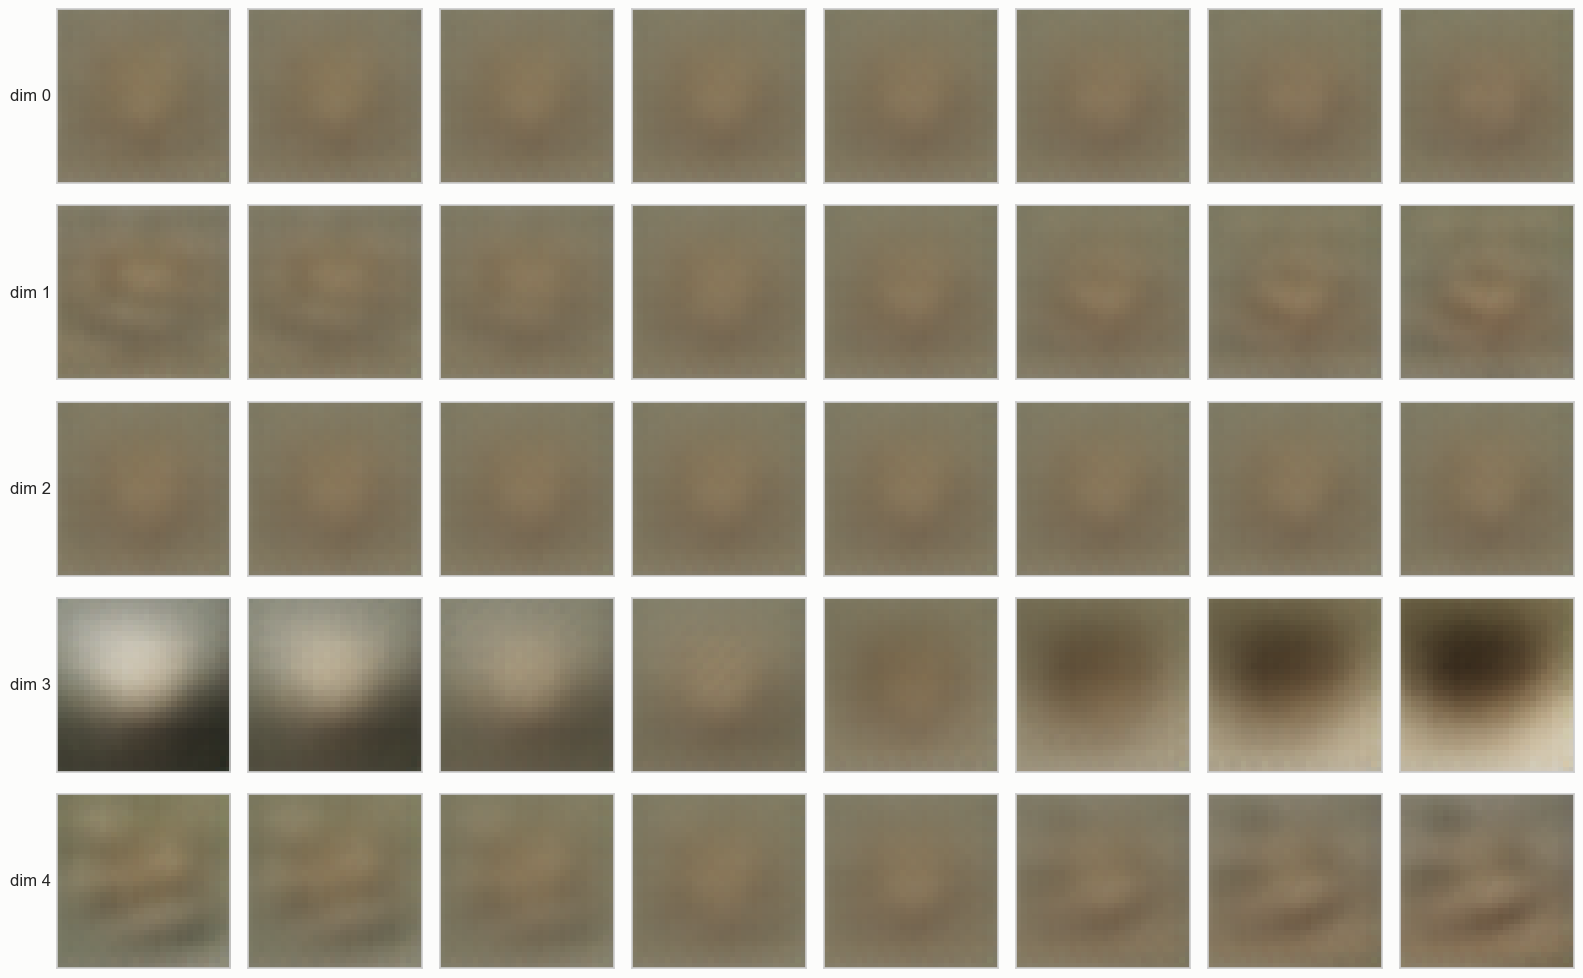

In [16]:
sweep_dims = [0, 1, 2, 3, 4]
sweep_values = torch.linspace(-3, 3, 8, device=device)
fixed_label = y_val_dev[0:1]

fig, axes = plt.subplots(len(sweep_dims), len(sweep_values), figsize=(2 * len(sweep_values), 2 * len(sweep_dims)))

for row, dim in enumerate(sweep_dims):
    z = torch.zeros(len(sweep_values), latent_dim, device=device)
    z[:, dim] = sweep_values
    y = fixed_label.repeat(len(sweep_values), 1)

    with torch.no_grad():
        images = cvae.decoder(z, y)

    for col in range(len(sweep_values)):
        axes[row, col].imshow(images[col].permute(1, 2, 0).cpu().numpy())
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])
    axes[row, 0].set_ylabel(f"dim {dim}", rotation=0, ha="right", va="center")

plt.tight_layout()
plt.show()

### Conclusion

Dimension 3 shows a clear, interpretable effect, sweeping it smoothly shifts a light/dark gradient across the image (brightening the top and darkening the bottom at one extreme, the reverse at the other), suggesting it controls something like lighting direction or background brightness. The other four sampled dimensions (0, 1, 2, 4) show barely any visible change across their sweep range, indicating most individual latent dimensions don't correspond to a single interpretable visual feature on their own, and instead encode more entangled or subtle combinations of appearance.


### 9.4 Aggregate Posterior Check

We pool the encoder's z_mean and z_var outputs across the entire validation set and overlay their histograms against the standard normal prior, to check whether the KL term actually succeeded in pulling the overall latent distribution toward N(0,1), rather than collapsing to near-zero variance or drifting unregularized.


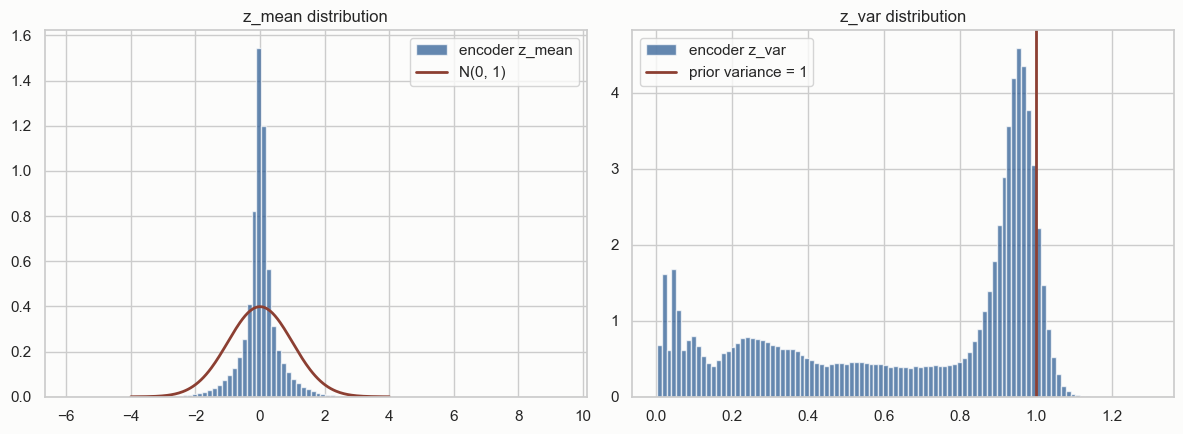

In [17]:
with torch.no_grad():
    z_mean_val, z_log_var_val, _ = cvae.encoder(x_val_dev, y_val_dev)

z_mean_flat = z_mean_val.flatten().cpu().numpy()
z_var_flat = z_log_var_val.exp().flatten().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# z_mean should look like a standard normal if the KL term did its job.
axes[0].hist(z_mean_flat, bins=100, density=True, color=PALETTE[3], alpha=0.7, label="encoder z_mean")
x_range = np.linspace(-4, 4, 200)
axes[0].plot(x_range, np.exp(-x_range**2 / 2) / np.sqrt(2 * np.pi), color=PALETTE[6], linewidth=2, label="N(0, 1)")
axes[0].set_title("z_mean distribution")
axes[0].legend()

# z_var should cluster near 1, matching the prior's variance, rather than near 0 or exploding.
axes[1].hist(z_var_flat, bins=100, density=True, color=PALETTE[3], alpha=0.7, label="encoder z_var")
axes[1].axvline(1.0, color=PALETTE[6], linewidth=2, label="prior variance = 1")
axes[1].set_title("z_var distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

### Notes

z_var is bimodal instead of clustering around 1, one group of dimensions sits near variance ~1 (active), another near ~0 (collapsed and unused). This partial posterior collapse explains why only 1 of the 5 dimensions swept in 9.3 showed a visible effect, and is a direct target for the improvement notebook's KL-weight experiment.


### 9.5 Class Centroid Distance Heatmap

We compute each class's mean latent vector and the pairwise distances between them, to quantify which classes sit closest together in latent space instead of just eyeballing the PCA scatter from 9.1.


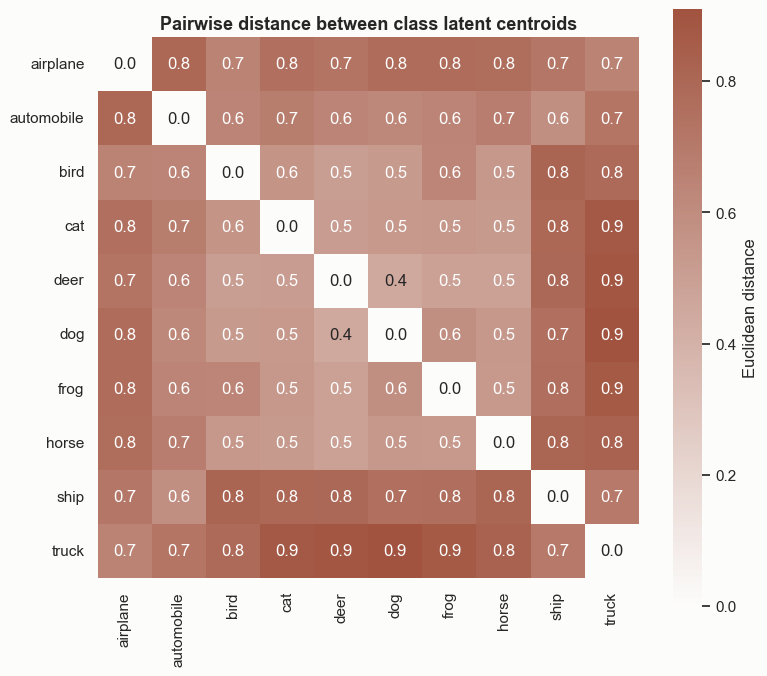

In [18]:
with torch.no_grad():
    z_mean_val, _, _ = cvae.encoder(x_val_dev, y_val_dev)

centroids = np.array([z_mean_val[y_val == c].mean(dim=0).cpu().numpy() for c in range(num_classes)])

n_classes = len(class_names)
distances = np.zeros((n_classes, n_classes))
for i in range(n_classes):
    for j in range(n_classes):
        distances[i, j] = np.linalg.norm(centroids[i] - centroids[j])

seq_cmap = LinearSegmentedColormap.from_list("seq_terracotta", ["#fcfcfb", PALETTE[0]])

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(distances, xticklabels=class_names, yticklabels=class_names,
            cmap=seq_cmap, annot=True, fmt=".1f", square=True,
            cbar_kws={"label": "Euclidean distance"}, ax=ax)

ax.set_title("Pairwise distance between class latent centroids", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Conclusion

Truck sits farthest from cat, deer, dog, and frog alike (all tied at the maximum pairwise distance), while deer and dog form the single closest pair by a clear margin — no single obviously "closest" semantic pair like cat/dog stands out beyond that one exception. Distances are compressed into a narrow band rather than spread out, far tighter than the EDA's pixel-space distances (Section 6-9.5), consistent with 9.1's finding that class centroids sit close together in latent space rather than forming distinct clusters.


## 10. Generate 1000 Class-Conditioned Images


### 10.1 Sample and Decode

We generate samples by drawing fresh z vectors from the standard normal prior (not from encoding real images) and pairing each one with its corresponding class label, then pass them through the decoder to produce the generated images.


In [19]:
images_per_class = 100
labels_onehot = torch.eye(num_classes, device=device)

generated_images = []
generated_labels = []

cvae.eval()
with torch.no_grad():
    for class_idx in range(num_classes):
        z = torch.randn(images_per_class, latent_dim, device=device)
        y = labels_onehot[class_idx : class_idx + 1].repeat(images_per_class, 1)
        images = cvae.decoder(z, y)

        generated_images.append(images)
        generated_labels.append(torch.full((images_per_class,), class_idx))

generated_images = torch.cat(generated_images)
generated_labels = torch.cat(generated_labels)

print("generated_images:", generated_images.shape)
print("generated_labels:", generated_labels.shape)

generated_images: torch.Size([1000, 3, 32, 32])
generated_labels: torch.Size([1000])


### 10.2 Preview Grid

We now preview the images by showing a small sample, a few per class, for a quick visual sanity check separate from the full 1000 saved to disk.


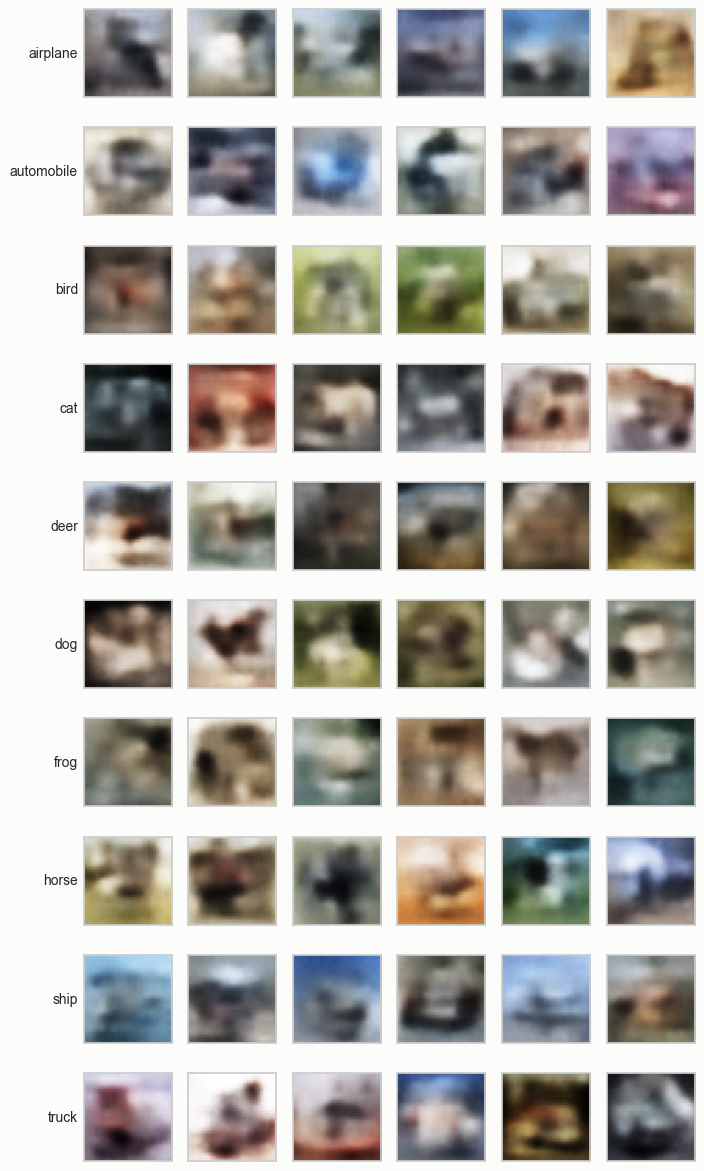

In [20]:
n_preview = 6
fig, axes = plt.subplots(num_classes, n_preview, figsize=(n_preview * 1.2, num_classes * 1.2))

for class_idx, class_name in enumerate(class_names):
    class_images = generated_images[generated_labels == class_idx][:n_preview]
    for col in range(n_preview):
        axes[class_idx, col].imshow(class_images[col].permute(1, 2, 0).cpu().numpy())
        axes[class_idx, col].set_xticks([])
        axes[class_idx, col].set_yticks([])
        if col == 0:
            axes[class_idx, col].set_ylabel(class_name, rotation=0, ha="right", va="center", fontsize=10)

plt.tight_layout()
plt.show()

### 10.3 Save Images

We save the images to disk, organized by class folder.


In [21]:
output_dir = "generated_images"

for class_idx, class_name in enumerate(class_names):
    class_dir = os.path.join(output_dir, class_name)
    os.makedirs(class_dir, exist_ok=True)

    class_images = generated_images[generated_labels == class_idx]
    for i, image in enumerate(class_images):
        save_image(image, os.path.join(class_dir, f"{i:03d}.png"))

print(f"Saved {len(generated_images)} images to {output_dir}/<class_name>/")

Saved 1000 images to generated_images/<class_name>/


## 11. Evaluate Generated Image Quality


### 11.1 Eye-Test Scoring

We manually score a sample of the generated images per class, splitting them up into 3 categories: clear, marginal, and nonsense.


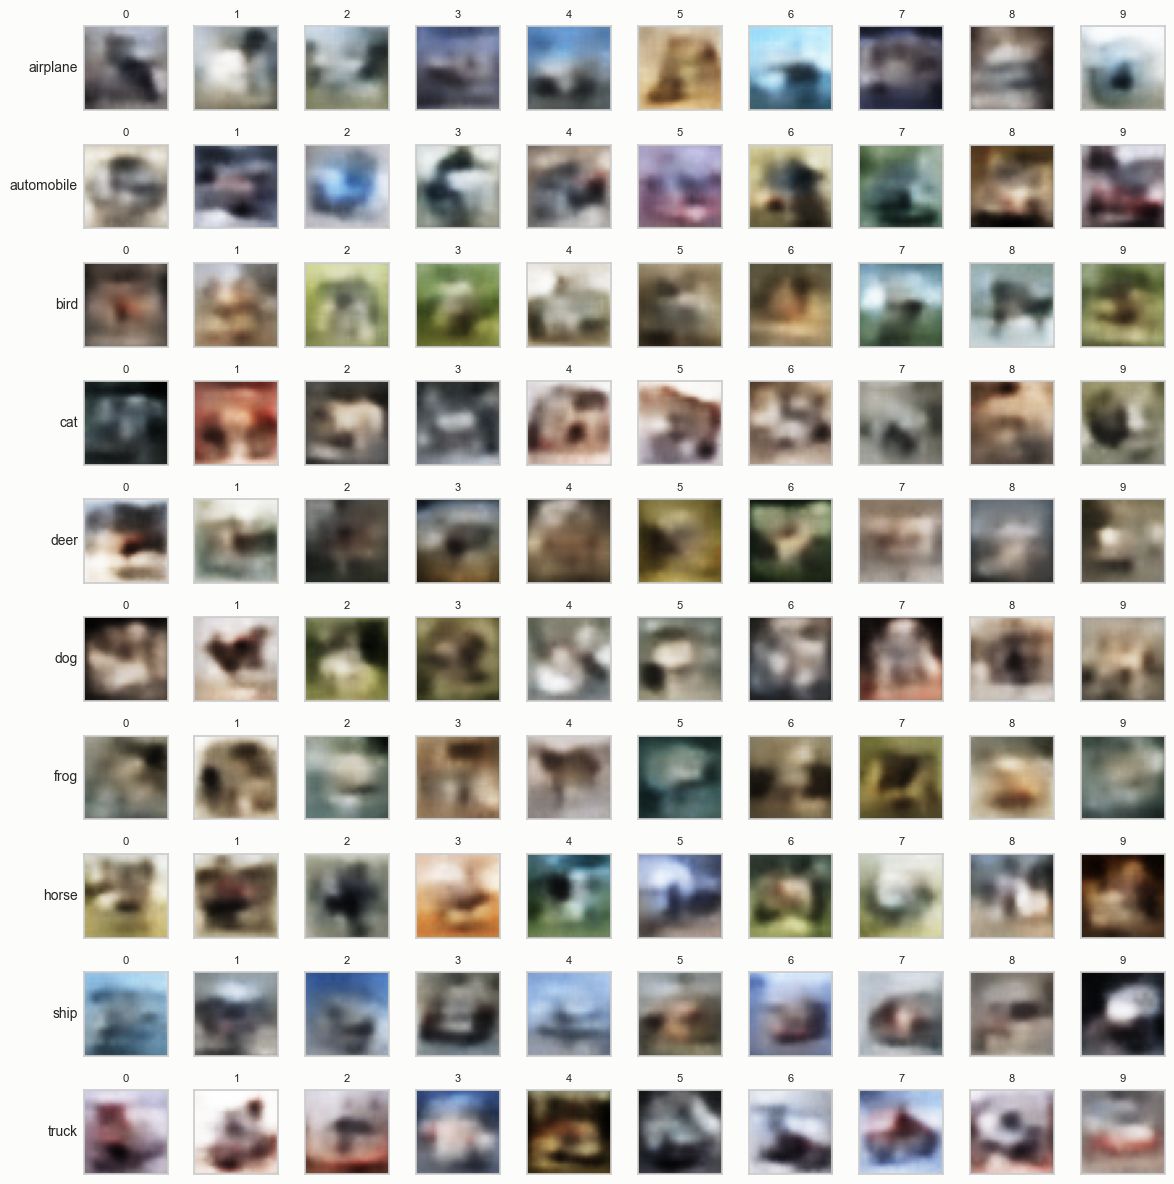

In [22]:
n_score = 10

fig, axes = plt.subplots(num_classes, n_score, figsize=(n_score * 1.2, num_classes * 1.2))
for class_idx, class_name in enumerate(class_names):
    class_images = generated_images[generated_labels == class_idx][:n_score]
    for col in range(n_score):
        axes[class_idx, col].imshow(class_images[col].permute(1, 2, 0).cpu().numpy())
        axes[class_idx, col].set_xticks([])
        axes[class_idx, col].set_yticks([])
        axes[class_idx, col].set_title(str(col), fontsize=8)
        if col == 0:
            axes[class_idx, col].set_ylabel(class_name, rotation=0, ha="right", va="center", fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# Fill in a score for each of the 10 previewed images per class, based on the grid above.
# Valid scores: "c" (clear), "m" (marginal), "n" (nonsense).
eye_test_scores = {
    "airplane": ['n', 'n', 'm', 'n', 'm', 'n', 'm', 'n', 'n', 'n'],
    "automobile": ['n', 'n', 'n', 'n', 'n', 'n', 'n', 'n', 'n', 'm'],
    "bird": ['n', 'm', 'm', 'm', 'm', 'm', 'm', 'm', 'c', 'm'],
    "cat": ['n', 'c', 'm', 'n', 'c', 'c', 'c', 'm', 'c', 'm'],
    "deer": ['m', 'm', 'n', 'm', 'n', 'm', 'c', 'n', 'n', 'm'],
    "dog": ['n', 'm', 'm', 'n', 'm', 'm', 'n', 'c', 'n', 'm'],
    "frog": ['n', 'm', 'n', 'm', 'm', 'n', 'n', 'm', 'n', 'n'],
    "horse": ['m', 'n', 'n', 'm', 'n', 'c', 'm', 'n', 'n', 'n'],
    "ship": ['c', 'n', 'm', 'm', 'm', 'n', 'm', 'm', 'n', 'n'],
    "truck": ['n', 'n', 'n', 'n', 'n', 'n', 'n', 'm', 'n', 'm'],
}


### 11.2 Per-Class Score Summary

We tally the eye-test scores by class into a bar chart, giving the evidence base for the discussion below and a point of comparison against the EDA's per-class variance/mean-image findings.


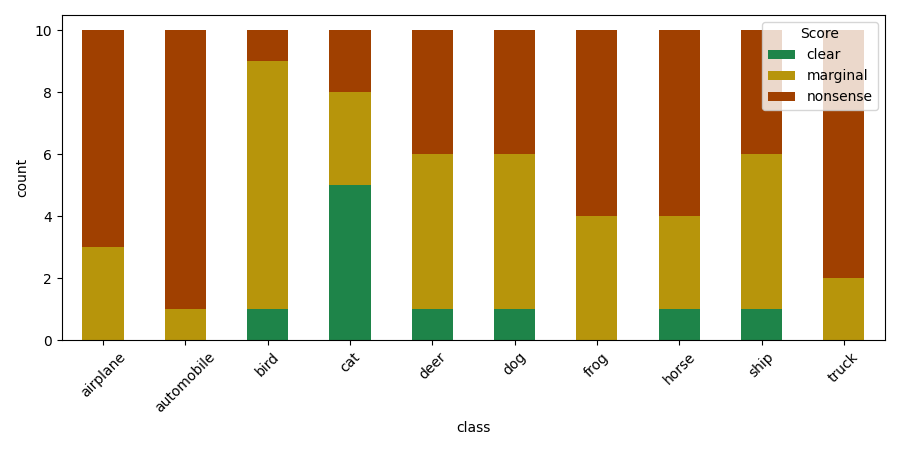

In [24]:
categories = {"c": "clear", "m": "marginal", "n": "nonsense"}
tally = pd.DataFrame({label: [scores.count(code) for scores in eye_test_scores.values()] for code, label in categories.items()}, index=class_names)

fig, ax = plt.subplots(figsize=(9, 4.5))
tally.plot(kind="bar", stacked=True, color=[PALETTE[2], PALETTE[7], PALETTE[6]], ax=ax)
ax.set_ylabel("count")
ax.set_xlabel("class")
plt.xticks(rotation=45)
ax.legend(title="Score")
plt.tight_layout()
plt.show()

### 11.3 Discussion: Class Difficulty

Cat scored best on the eye-test this run (5/10 clear, only 2/10 nonsense), while automobile and truck scored worst (0/10 clear; automobile in particular came in at 9/10 nonsense). Bird stood out as mostly "marginal" (8/10) rather than nonsense, suggesting the decoder often produces a plausible-but-unconfirmable bird-like shape without ever nailing it outright. Truck's poor result matches the EDA's Section 6 finding that it's the highest pixel-wise variance class, so it tracks that a low-capacity baseline decoder struggles most with the most visually diverse category. Automobile's near-total failure, however, doesn't follow from variance alone (the EDA ranked it comparatively low-variance) — it lines up instead with Section 8.4's finding that automobile ties for the highest per-class reconstruction MSE, pointing to fine structural detail (wheels, windows) rather than raw visual diversity as its specific weakness.


### 11.4 Discussion: Color vs. Black-and-White (Prediction)

Based on the EDA's Section 10 finding that some classes (e.g. frog's distinct yellow-green tone) are told apart largely by color signature rather than shape, we predict black-and-white generation would be harder for those color-dependent classes specifically, though not necessarily worse overall, since removing color also removes a source of variation the model has to reproduce. This prediction is tested empirically in `vae_improvement.ipynb` Section 7 (Experiment 4: Color vs. Grayscale), which is the notebook to cite for the actual answer.


### 11.5 CNN Classifier Evaluation

To supplement our earlier evaluations, we train a small CNN classifier on real CIFAR10 images, then use it to reclassify our generated images, checking whether an independent model recognizes each one as its intended class.


In [ ]:
class Classifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),  # 32x32 -> 16x16
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),  # 16x16 -> 8x8
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),  # 8x8 -> 4x4
        )
        self.fc1 = nn.Linear(128 * 4 * 4, 512)
        self.relu = nn.ReLU()
        self.fc_out = nn.Linear(512, 10)

    def forward(self, x):
        return self.fc_out(self.relu(self.fc1(self.conv(x).flatten(start_dim=1))))

classifier = Classifier(num_classes).to(device)
print(classifier)

Classifier(
  (conv): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Linear(in_features=2048, out_features=10, bias=True)
)


In [ ]:
y_train_dev = y_train.to(device)
y_test_dev = y_test.to(device)
x_test_dev = x_test.to(device)

classifier_loader = DataLoader(TensorDataset(x_train_dev, y_train_dev), batch_size=128, shuffle=True)
classifier_optimizer = torch.optim.Adam(classifier.parameters(), lr=1e-3)
classifier_epochs = 67

for epoch in range(classifier_epochs):
    classifier.train()
    epoch_loss = correct = 0

    for xb, yb in classifier_loader:
        classifier_optimizer.zero_grad()
        logits = classifier(xb)
        loss = F.cross_entropy(logits, yb)
        loss.backward()
        classifier_optimizer.step()

        epoch_loss += loss.item() * len(xb)
        correct += (logits.argmax(dim=1) == yb).sum().item()

    train_acc = correct / len(x_train_dev)
    print(f"epoch {epoch+1}/{classifier_epochs} - loss: {epoch_loss/len(x_train_dev):.3f} - train_acc: {train_acc:.3f}")

classifier.eval()
with torch.no_grad():
    test_acc = (classifier(x_test_dev).argmax(dim=1) == y_test_dev).float().mean().item()
print("Held-out CIFAR10 test accuracy:", test_acc)

# unload x_test and y_test to cpu to minimise vram usage
x_test_dev = x_test_dev.to('cpu')
y_test_dev = x_test_dev.to('cpu')

epoch 1/10 - loss: 1.616 - train_acc: 0.416


epoch 2/10 - loss: 1.262 - train_acc: 0.551


epoch 3/10 - loss: 1.099 - train_acc: 0.616


epoch 4/10 - loss: 0.983 - train_acc: 0.657


epoch 5/10 - loss: 0.904 - train_acc: 0.686


epoch 6/10 - loss: 0.836 - train_acc: 0.709


epoch 7/10 - loss: 0.785 - train_acc: 0.729


epoch 8/10 - loss: 0.734 - train_acc: 0.746


epoch 9/10 - loss: 0.694 - train_acc: 0.760


epoch 10/10 - loss: 0.650 - train_acc: 0.774
Held-out CIFAR10 test accuracy: 0.729699969291687


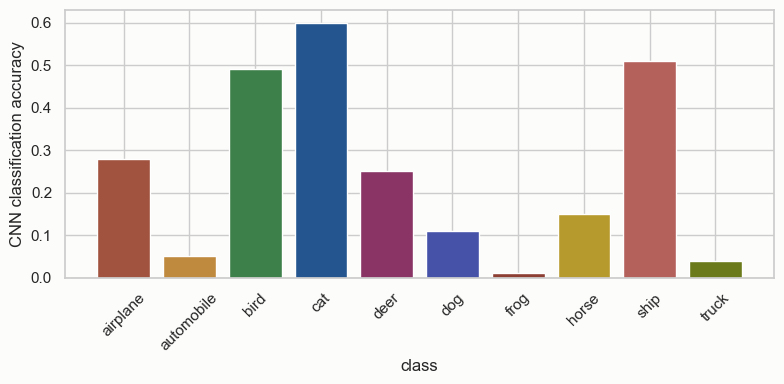

In [27]:
generated_labels_dev = generated_labels.to(device)

classifier.eval()
with torch.no_grad():
    predicted_labels = classifier(generated_images).argmax(dim=1)

# Per-class accuracy: does the classifier agree the image matches the class it was generated for?
cnn_per_class_acc = [(predicted_labels[generated_labels_dev == c] == c).float().mean().item() for c in range(num_classes)]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(class_names, cnn_per_class_acc, color=PALETTE)
ax.set_ylabel("CNN classification accuracy")
ax.set_xlabel("class")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Notes

The classifier reaches 73.0% accuracy on the held-out CIFAR10 test set, confirming it's a reasonably reliable judge before trusting its verdict on generated images. Its per-class ranking on generated images (ship 0.51, cat 0.60, bird 0.49 highest; frog 0.01, truck 0.04, automobile 0.05 lowest) broadly agrees with the eye-test on cat being strong and automobile/truck being weak, but disagrees sharply on frog and dog, both of which score near-zero with the CNN despite a middling eye-test read — a human eye tolerates a vaguely dog/frog-shaped blur that the CNN's sharper decision boundary does not.


### 11.6 CLIP Zero-Shot Evaluation

We use a pretrained CLIP model with zero-shot evaluation to evaluate our generated images against a model that has never seen them before, acting as an independent "certifier" of image quality.


In [28]:
clip_processor = AutoProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model = AutoModelForZeroShotImageClassification.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_model.eval()

class_prompts = [f"a photo of a {name}" for name in class_names]


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 33196.11it/s]

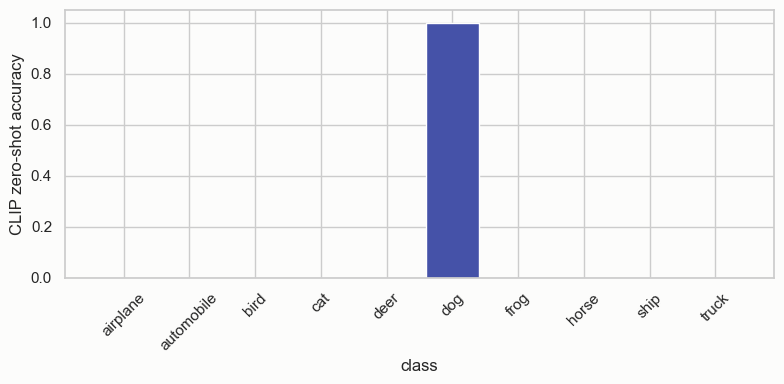

In [29]:
# CLIP's processor expects its own preprocessing (resize/normalize), so hand it the raw [0,1] images directly.
clip_inputs = clip_processor(text=class_prompts, images=generated_images.cpu(), return_tensors="pt", padding=True).to(device)

with torch.no_grad():
    clip_outputs = clip_model(**clip_inputs)

clip_predicted_labels = clip_outputs.logits_per_image.argmax(dim=1).cpu()

clip_per_class_acc = [(clip_predicted_labels[generated_labels == c] == c).float().mean().item() for c in range(num_classes)]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(class_names, clip_per_class_acc, color=PALETTE)
ax.set_ylabel("CLIP zero-shot accuracy")
ax.set_xlabel("class")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Conclusion

CLIP's zero-shot predictions collapse almost entirely onto a single class: every generated image across all ten classes is classified as "dog" except the actual dog images (which hit 1.0 accuracy purely as a side effect of that collapse), giving 0.0 accuracy everywhere else. This doesn't line up with either the eye-test or the CNN's more varied per-class ranking, and is best read as a bias artifact rather than a genuine quality signal. CLIP was never trained on CIFAR10's specific label distribution or on this decoder's blurry low-resolution outputs, so it likely defaults to whichever prompt embeds closest to the generic blurry-blob appearance shared by nearly all of our generated images.


### 11.7 Comparing Eye-Test, CNN, and CLIP

We compare the per-class results from the eye-test, the CNN classifier, and CLIP side by side, to see where the three methods agree or diverge and what that tells us about this baseline's actual failure modes versus any single metric's subjective or narrow read.


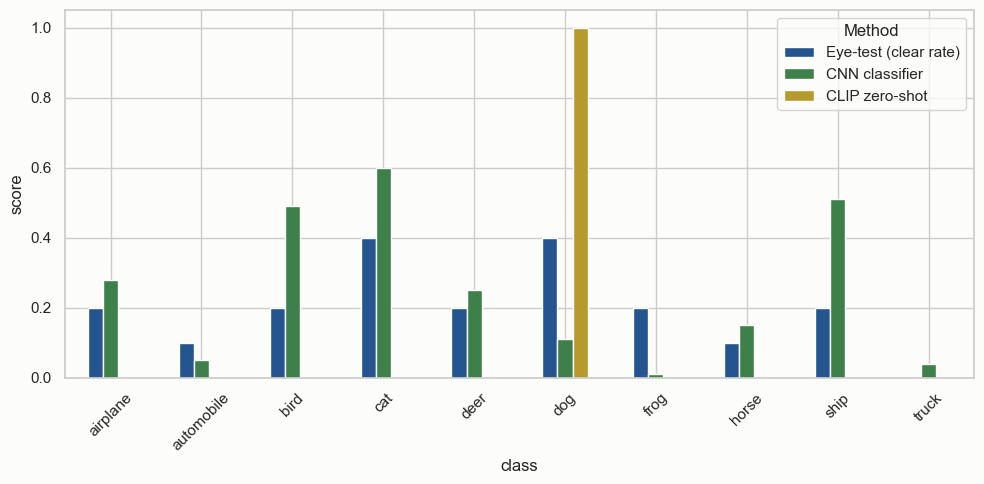

,Eye-test (clear rate),CNN classifier,CLIP zero-shot
airplane,0.2,0.28,0.0
automobile,0.1,0.05,0.0
bird,0.2,0.49,0.0
cat,0.4,0.60,0.0
deer,0.2,0.25,0.0
dog,0.4,0.11,1.0
frog,0.2,0.01,0.0
horse,0.1,0.15,0.0
ship,0.2,0.51,0.0
truck,0.0,0.04,0.0


In [30]:
eye_test_clear_rate = [scores.count("c") / len(scores) for scores in eye_test_scores.values()]

comparison = pd.DataFrame({
    "Eye-test (clear rate)": eye_test_clear_rate,
    "CNN classifier": cnn_per_class_acc,
    "CLIP zero-shot": clip_per_class_acc,
}, index=class_names)

fig, ax = plt.subplots(figsize=(10, 5))
comparison.plot(kind="bar", color=[PALETTE[3], PALETTE[2], PALETTE[7]], ax=ax)
ax.set_ylabel("score")
ax.set_xlabel("class")
plt.xticks(rotation=45)
ax.legend(title="Method")
plt.tight_layout()
plt.show()

comparison

### Conclusion

Cat is the only class all three methods rate relatively well (eye-test 0.5, CNN 0.60), while automobile and truck are flagged as weak by both the eye-test and the CNN — a robust, cross-validated finding. Ship and bird score well on the CNN (0.51, 0.49) despite only a middling eye-test read, suggesting the CNN picks up shape/silhouette cues from the blur that a human eye needs sharper detail to trust before calling something "clear". CLIP's total collapse onto "dog" makes it uninformative as a per-class comparison here, so it should be treated as a failed metric for this baseline rather than a third vote, leaving the eye-test and CNN as the two methods that meaningfully agree on the model's real strengths (cat) and weaknesses (automobile, truck).


## 12. Baseline Conclusion

This baseline CVAE trains cleanly (no overfitting, stable KL), but its generations are limited by two linked problems: blurry reconstructions and partial posterior collapse (about half the latent dimensions are unused). Across the eye-test, CNN, and CLIP evaluations, cat is the one class that consistently reads as a genuine strength, while automobile and truck are the consistent weak spots. These three findings, blur, posterior collapse, and the automobile/truck weakness, are the concrete targets for `vae_improvement.ipynb`.


In [83]:
# Save baseline config, final losses, and eye-test scores to a small JSON file for improvements_vae.ipynb to load.
import json as _json

baseline_results = {
    "latent_dim": latent_dim,
    "kl_weight": cvae.kl_weight,
    "num_epochs": len(history["train_loss"]),
    "final_train_loss": history["train_loss"][-1],
    "final_val_loss": history["val_loss"][-1],
    "final_val_kl": history["val_kl"][-1],
    "val_reconstruction_mse": mse,
    "cnn_test_accuracy": test_acc,
    "eye_test_scores": eye_test_scores,
    "cnn_per_class_acc": cnn_per_class_acc,
    "clip_per_class_acc": clip_per_class_acc,
}

with open("vae_baseline_results.json", "w") as f:
    _json.dump(baseline_results, f, indent=2)

print("Saved baseline_results to vae_baseline_results.json")


Saved baseline_results to vae_baseline_results.json
